конфиг ок: 9 классов, id 0..8
без данных: ['8 Drilling rig']

 id  класс                      боксов   судьба
------------------------------------------------------------------
  0  Dump truck                   7048   -> 0 Dump truck
  1  Excavator                    8283   -> 1 Excavator
  2  Motor grader                  667   -> 2 Bucket loader
  3  Roller                         21   удаляем  (похож на оставленные)
  4  Crane manipulator             847   -> 5 Crane manipulator
  5  Gazelle                      4883   удаляем
  6  Forklift Standard             971   -> 7 Forklift
  7  Bucket loader Big            2454   -> 2 Bucket loader
  8  Mixer                        1224   -> 4 Mixer
  9  Tanker                        427   удаляем  (похож на оставленные)
 10  Bulldozer                       1   -> 3 Bulldozer
 11  Cleaning equipment            865   удаляем
 12  Truck                        1305   удаляем  (похож на оставленные)
 13  Trailer                      1830   удаля

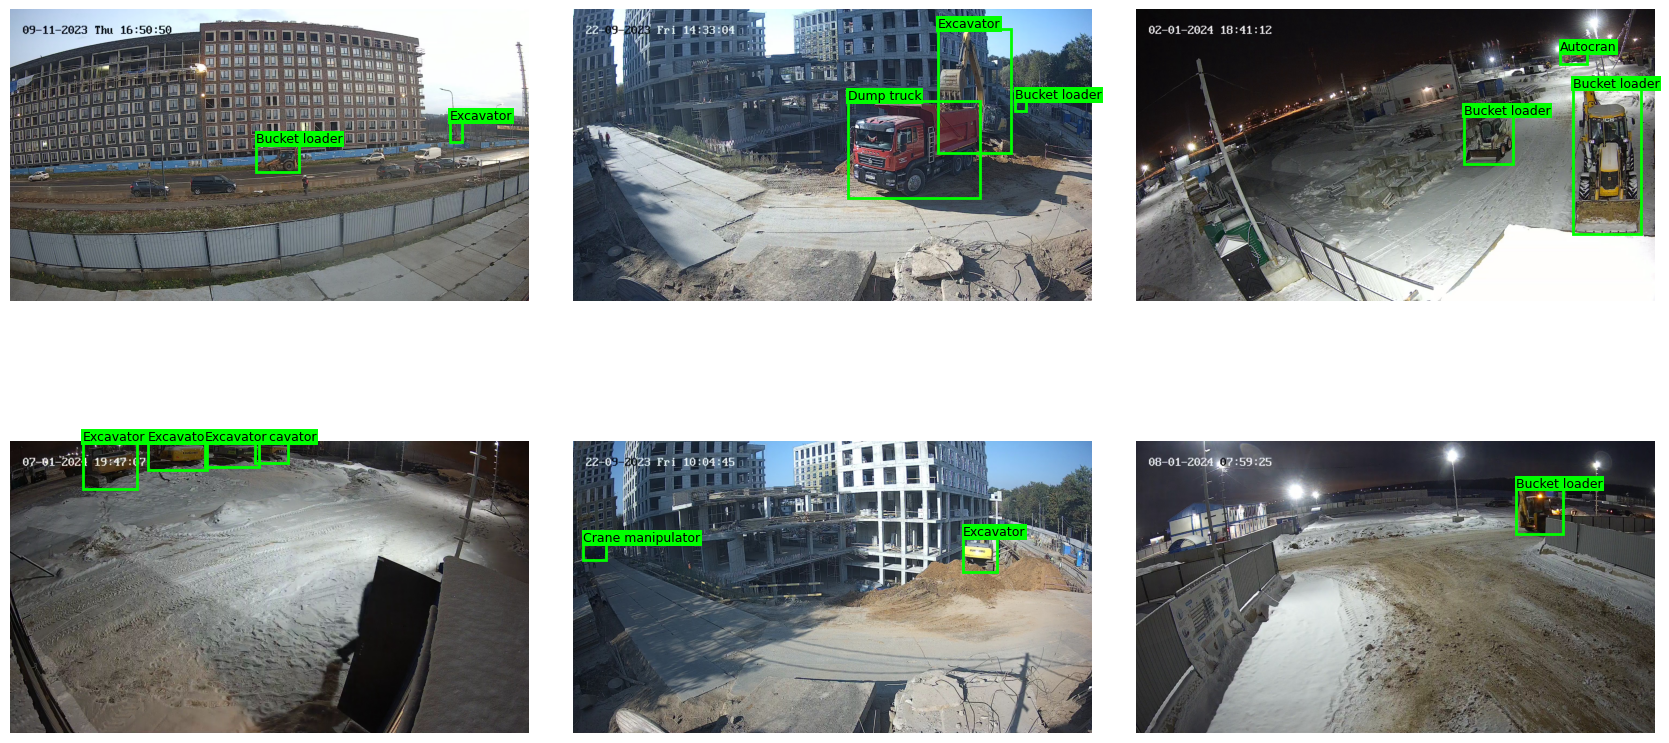

In [1]:
import os, shutil, random
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# ──────────────────────────── КОНФИГ ────────────────────────────

SRC = Path("/kaggle/input/datasets/xyzyxzzxy/construction-equipment")
DST = Path("/kaggle/working/dataset")

SPLITS = {"train": "train", "valid": "val"}
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
LINK_IMAGES = False

DROP_EMPTY_FRAMES = "smart"

CLASS_NAMES = [
    "Dump truck",         # 0
    "Excavator",          # 1
    "Bucket loader",      # 2
    "Bulldozer",          # 3
    "Mixer",              # 4
    "Crane manipulator",  # 5
    "Autocran",           # 6
    "Forklift",           # 7
    "Drilling rig",       # 8
]

OLD_TO_NEW = {
    0:  0,   # Dump truck
    1:  1,   # Excavator
    2:  2,   # Motor grader           -> Bucket loader
    7:  2,   # Bucket loader Big      -> Bucket loader
    15: 2,   # Bucket loader Standard -> Bucket loader
    10: 3,   # Bulldozer
    8:  4,   # Mixer
    4:  5,   # Crane manipulator
    16: 6,   # Autocran
    6:  7,   # Forklift Standard
}

# 12 Truck, 13 Trailer, 9 Tanker, 5 Gazelle, 14 Forklift Giraffe, 3 Roller
CONFUSABLE_OLD = {12, 13, 9, 14, 3}

OLD_NAMES = [
    "Dump truck", "Excavator", "Motor grader", "Roller", "Crane manipulator",
    "Gazelle", "Forklift Standard", "Bucket loader Big", "Mixer", "Tanker",
    "Bulldozer", "Cleaning equipment", "Truck", "Trailer", "Forklift Giraffe",
    "Bucket loader Standard", "Autocran",
]

# ──────────────────────── ПРОВЕРКА КОНФИГА ──────────────────────

assert SRC.exists(), f"нет пути {SRC}"
for s in SPLITS:
    assert (SRC / s / "images").exists(), f"нет {SRC / s / 'images'}"
    assert (SRC / s / "labels").exists(), f"нет {SRC / s / 'labels'}"

used = sorted(set(OLD_TO_NEW.values()))
assert max(used) < len(CLASS_NAMES), "новый id выходит за CLASS_NAMES"
gaps = [i for i in range(max(used)) if i not in used]
assert not gaps, f"дырки в нумерации: {gaps}"

print(f"конфиг ок: {len(CLASS_NAMES)} классов, id 0..{len(CLASS_NAMES) - 1}")
print("без данных:", [f"{i} {CLASS_NAMES[i]}"
                      for i in range(len(CLASS_NAMES)) if i not in used])

# ──────────────────── ЧТО ЛЕЖИТ В ИСХОДНИКЕ ─────────────────────

src_counts = Counter()
for s in SPLITS:
    for lbl in (SRC / s / "labels").glob("*.txt"):
        for line in lbl.read_text().splitlines():
            if line.strip():
                src_counts[int(float(line.split()[0]))] += 1

total = sum(src_counts.values())
print(f"\n{'id':>3}  {'класс':<24} {'боксов':>8}   судьба")
print("-" * 66)
for cid in range(len(OLD_NAMES)):
    n = src_counts.get(cid, 0)
    if cid in OLD_TO_NEW:
        fate = f"-> {OLD_TO_NEW[cid]} {CLASS_NAMES[OLD_TO_NEW[cid]]}"
    else:
        fate = "удаляем" + ("  (похож на оставленные)" if cid in CONFUSABLE_OLD else "")
    print(f"{cid:>3}  {OLD_NAMES[cid]:<24} {n:>8}   {fate}")

keep = sum(n for c, n in src_counts.items() if c in OLD_TO_NEW)
print("-" * 66)
print(f"всего {total}, остаётся {keep} ({keep / max(total, 1):.0%})")

# ───────────────────────────── СБОРКА ───────────────────────────

def find_image(img_dir: Path, stem: str):
    for e in IMG_EXTS:
        p = img_dir / (stem + e)
        if p.exists():
            return p
    return None


def prepare(split_src: str, split_dst: str):
    src_lbl, src_img = SRC / split_src / "labels", SRC / split_src / "images"
    out_lbl, out_img = DST / split_dst / "labels", DST / split_dst / "images"
    out_lbl.mkdir(parents=True, exist_ok=True)
    out_img.mkdir(parents=True, exist_ok=True)

    stats, per_class = Counter(), Counter()

    for lbl in sorted(src_lbl.glob("*.txt")):
        img = find_image(src_img, lbl.stem)
        if img is None:
            stats["label_without_image"] += 1
            continue

        kept, had_confusable = [], False
        for line in lbl.read_text().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            old = int(float(parts[0]))
            if old in OLD_TO_NEW:
                kept.append(" ".join([str(OLD_TO_NEW[old])] + parts[1:]))
            else:
                stats["boxes_dropped"] += 1
                if old in CONFUSABLE_OLD:
                    had_confusable = True

        if not kept and DROP_EMPTY_FRAMES in (True, "smart"):
            stats["skipped_empty"] += 1
            continue
        if kept and had_confusable and DROP_EMPTY_FRAMES == "smart":
            stats["skipped_confusable"] += 1
            continue

        (out_lbl / lbl.name).write_text("\n".join(kept) + ("\n" if kept else ""))
        dst_img = out_img / img.name
        if not dst_img.exists():
            os.symlink(img, dst_img) if LINK_IMAGES else shutil.copy2(img, dst_img)

        for k in kept:
            per_class[int(k.split()[0])] += 1
        stats["frames_kept"] += 1
        stats["boxes_kept"] += len(kept)

    return stats, per_class


if DST.exists():
    shutil.rmtree(DST)

grand = Counter()
for s_src, s_dst in SPLITS.items():
    stats, per_class = prepare(s_src, s_dst)
    grand += per_class
    print(f"\n[{s_dst}]")
    for k, v in stats.items():
        print(f"    {k:<22} {v}")
    print("    ---")
    for cid in range(len(CLASS_NAMES)):
        print(f"    {cid:>2} {CLASS_NAMES[cid]:<20} {per_class.get(cid, 0)}")

# ──────────────────────────── ЧИСТКА ────────────────────────────

def sweep(root=DST, splits=("train", "val"), drop_empty_labels=True):
    """Удаляет изображения без разметки, разметку без изображений и пустые txt."""
    for s in splits:
        img_dir, lbl_dir = root / s / "images", root / s / "labels"
        images = {p.stem: p for p in img_dir.glob("*") if p.suffix.lower() in IMG_EXTS}
        labels = {p.stem: p for p in lbl_dir.glob("*.txt")}

        no_label = set(images) - set(labels)
        no_image = set(labels) - set(images)
        empty = ({k for k, v in labels.items() if not v.read_text().strip()}
                 if drop_empty_labels else set())

        for k in no_label:
            images[k].unlink()
        for k in no_image:
            labels[k].unlink()
        for k in empty:
            labels[k].unlink()
            if k in images and images[k].exists():
                images[k].unlink()

        left = len([p for p in img_dir.glob("*") if p.suffix.lower() in IMG_EXTS])
        print(f"[{s}] удалено: без разметки {len(no_label)}, без картинки {len(no_image)}, "
              f"пустых {len(empty)}  ->  осталось {left}")


def materialize(root=DST):
    """Заменяет симлинки реальными копиями. Нужно только при LINK_IMAGES = True."""
    n, mb = 0, 0
    for p in root.rglob("*"):
        if p.is_symlink():
            real = p.resolve()
            p.unlink()
            shutil.copy2(real, p)
            n += 1
            mb += p.stat().st_size / 1e6
    print(f"скопировано {n} файлов, {mb:.0f} МБ")


print()
sweep()
if LINK_IMAGES:
    materialize()

# ──────────────────────────── data.yaml ─────────────────────────

yaml_text = (
    f"path: {DST}\n"
    "train: train/images\n"
    "val: val/images\n\n"
    f"nc: {len(CLASS_NAMES)}\n"
    "names:\n"
    + "".join(f"  {i}: {n}\n" for i, n in enumerate(CLASS_NAMES))
)
(DST / "data.yaml").write_text(yaml_text)
print("\n" + yaml_text)

# ───────────────────────── ФОРМАЛЬНЫЕ ПРОВЕРКИ ──────────────────

problems = []
for s in SPLITS.values():
    lbls = list((DST / s / "labels").glob("*.txt"))
    imgs = [p for p in (DST / s / "images").glob("*") if p.suffix.lower() in IMG_EXTS]
    real = sum(1 for p in imgs if not p.is_symlink())
    print(f"{s}: {len(imgs)} изображений ({real} реальных файлов), {len(lbls)} разметок")
    if len(imgs) != len(lbls):
        problems.append(f"{s}: images != labels")

    for lbl in lbls:
        if find_image(DST / s / "images", lbl.stem) is None:
            problems.append(f"{lbl} без картинки")
        for i, line in enumerate(lbl.read_text().splitlines(), 1):
            p = line.split()
            if len(p) != 5:
                problems.append(f"{lbl}:{i} не 5 полей")
                continue
            if not 0 <= int(p[0]) < len(CLASS_NAMES):
                problems.append(f"{lbl}:{i} class_id={p[0]} вне диапазона")
            if any(not 0.0 <= float(v) <= 1.0 for v in p[1:]):
                problems.append(f"{lbl}:{i} координаты вне [0,1]")

print("\nпроблем:", len(problems))
for p in problems[:20]:
    print("   ", p)

# ────────────────────────── ПРОВЕРКА ГЛАЗАМИ ────────────────────

N = 6
d = DST / "train"
files = random.sample(list((d / "labels").glob("*.txt")), N)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, lbl in zip(axes.ravel(), files):
    im = Image.open(find_image(d / "images", lbl.stem))
    W, H = im.size
    ax.imshow(im)
    ax.axis("off")
    for line in lbl.read_text().splitlines():
        c, x, y, w, h = line.split()
        x, y, w, h = float(x) * W, float(y) * H, float(w) * W, float(h) * H
        ax.add_patch(patches.Rectangle((x - w / 2, y - h / 2), w, h,
                                       fill=False, lw=2, color="lime"))
        ax.text(x - w / 2, y - h / 2 - 5, CLASS_NAMES[int(c)],
                color="black", fontsize=9,
                bbox=dict(facecolor="lime", pad=1, edgecolor="none"))
plt.tight_layout()
plt.show()